In [1]:
import pandas as pd
import seaborn as sns
pd.options.display.precision = 2
import matplotlib.pyplot as plt
import json
import sys

In [2]:
sys.path.append('../')

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [4]:
Calc_date = 'Mar21_2026'

In [5]:
All_Teams_csv_path = League_path+'/Rosters'+f'/Kept_Players_and_Replacement_Level_{Calc_date}.csv'

In [6]:
All_Teams_df = pd.read_csv(All_Teams_csv_path)
All_Teams_df['FG ID'] = All_Teams_df['FG ID'].astype(str)
All_Teams_df['FG ID'] = All_Teams_df['FG ID'].str.replace('.0','')
All_Teams_df['Ottoneu ID'] = All_Teams_df['Ottoneu ID'].astype(str)
All_Teams_df['Ottoneu ID'] = All_Teams_df['Ottoneu ID'].str.replace('.0','')

In [7]:
Target_Stats_path = League_path+'/Target_Stats_dict.json'

In [8]:
Additional_targets = {
    'G_mySGP':162.*12.,
    'G_FGAV': 162.*12.,
    'IP_mySGP':1500.,
    'IP_FGAV':1500.,
    'TOTAL_SGP_Val_mySGP':500., #terget value for full team
    'CAT_SGP_Val':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'Salary': 380. #assume 10 for in-season pickups
}

In [9]:
with open(Target_Stats_path, 'r') as f:
    data = json.load(f)
    data.update(Additional_targets)
Target_Stats_df = pd.json_normalize(data)

In [10]:
Target_Stats_Hitter_df = Target_Stats_df[['Target Pts','R','HR','OBP','SLG','G_mySGP','G_FGAV','TOTAL_SGP_Val_mySGP','CAT_SGP_Val','Salary']]
Target_Stats_Hitter_df['Hitter Pitcher'] = 'Hitter'
Target_Stats_Pitcher_df = Target_Stats_df[['Target Pts','K','HR9','ERA','WHIP','IP_mySGP','IP_FGAV','TOTAL_SGP_Val_mySGP','CAT_SGP_Val','Salary']]
Target_Stats_Pitcher_df['Hitter Pitcher'] = 'Pitcher'
Target_Stats_Pitcher_df.rename(columns={'K':'SO'},inplace=True)
Target_Stats_df = pd.concat([
    Target_Stats_Hitter_df,
    Target_Stats_Pitcher_df
])

In [11]:
Target_Stats_df.head()

,Target Pts,R,HR,OBP,SLG,G_mySGP,G_FGAV,TOTAL_SGP_Val_mySGP,CAT_SGP_Val,Salary,Hitter Pitcher,SO,HR9,ERA,WHIP,IP_mySGP,IP_FGAV
0,10.44,1073.34,323.02,0.34,0.46,1944.0,1944.0,500.0,200.0,380.0,Hitter,NaN,NaN,NaN,NaN,NaN,NaN
0,10.44,NaN,NaN,NaN,NaN,NaN,NaN,500.0,200.0,380.0,Pitcher,1634.48,0.99,3.38,1.13,1500.0,1500.0


In [12]:
Player_id_cols = [
    'FG ID','Name','Team','Ottoneu ID','Ottoneu Positions'
]

In [13]:
Fantasy_Team_ID_cols = [
    'TeamID', 'Team Name',
]

In [14]:
Games_IP_Targets = {
    'C':162,
    '1B':162,
    '2B':162,
    '3B':162,
    'SS':162,
    'MI':162, 
    'OF':810, #total
    'Util':162, 
    'IP':1500 #total
}
Start_Spots = {
    'C':1, #technically 2 but 162 G limit
    '1B':1,
    '2B':1,
    'SS':1,
    'MI':1,
    '3B':1,
    'OF':5,
    'Util':1, #starting Hitters
    'SP':5,
    'RP':5
}

Total_Roster_Spots = {
    'C':2,
    '1B':2,
    '2B':3,
    'SS':3,
    '3B':2,
    'OF':9,
    'SP':9,
    'RP':6
}

In [15]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [16]:
Batting_value_columns = {
    'G':['TOTAL_SGP_Val_mySGP','G_mySGP_Team','PA_mySGP_Team','PA_FGAV_Team','Salary'],
    'R':['R_mySGP_Team','R_SGP_Val_mySGP_Team'], #'R_SGP_raw_mySGP','R_SGP_norm_mySGP','mR_FGAV'
    'HR':['HR_mySGP_Team','HR_SGP_Val_mySGP_Team'], # 'HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','mHR_FGAV'
    'OBP':['OBP_Team','OBP_SGP_Val_mySGP_Team'], # 'OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','mOBP_FGAV'
    'SLG':['SLG_Team','SLG_SGP_Val_mySGP_Team'] #'SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP',,'mSLG_FGAV'
}

Pitching_value_columns = {
    'IP':['TOTAL_SGP_Val_mySGP','IP_mySGP_Team','IP_FGAV_Team','Salary'],
    'SO':['SO_mySGP_Team','SO_SGP_Val_mySGP_Team'], # 'SO_SGP_raw_mySGP','SO_SGP_norm_mySGP',,'mSO_FGAV'
    'HR9':['HR9_Team','HR9_SGP_Val_mySGP_Team'], #'HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP', ,'mHR_FGAV'
    'ERA':['ERA_Team','ERA_SGP_Val_mySGP_Team'], # 'ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP',,'mERA_FGAV'
    'WHIP':['WHIP_Team','WHIP_SGP_Val_mySGP_Team'] # 'WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP',,'mWHIP_FGAV'
}

Team_Rate_Cols = [
    'HR9_Team',
    'ERA_Team',
    'WHIP_Team',
    'OBP_Team',
    'SLG_Team'
]

In [17]:
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'MI',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [18]:
def quick_plotting_fn(quick_plot, title):
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(111)
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel(title)
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    plt.tick_params(axis='y', which='major', labelsize=7)
    plt.show()

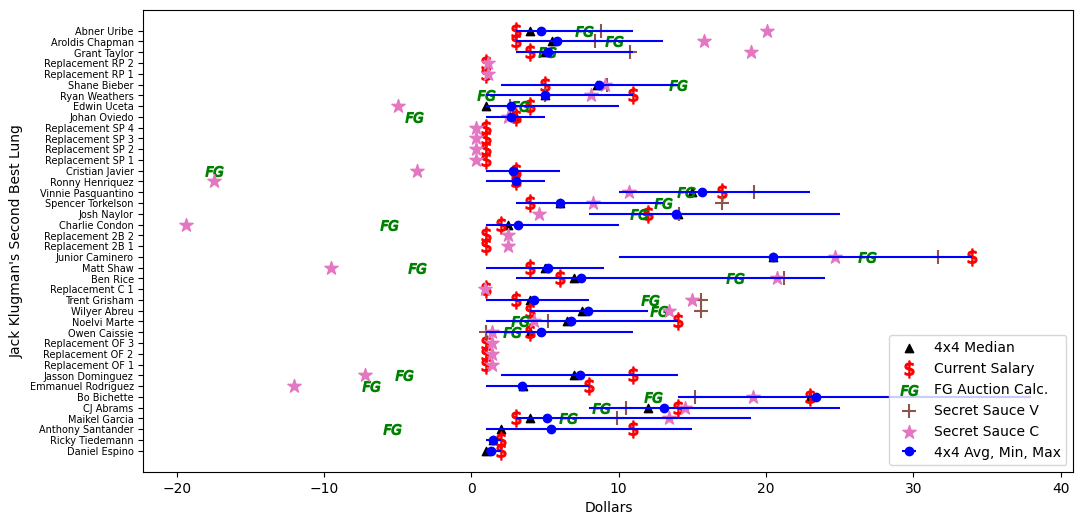

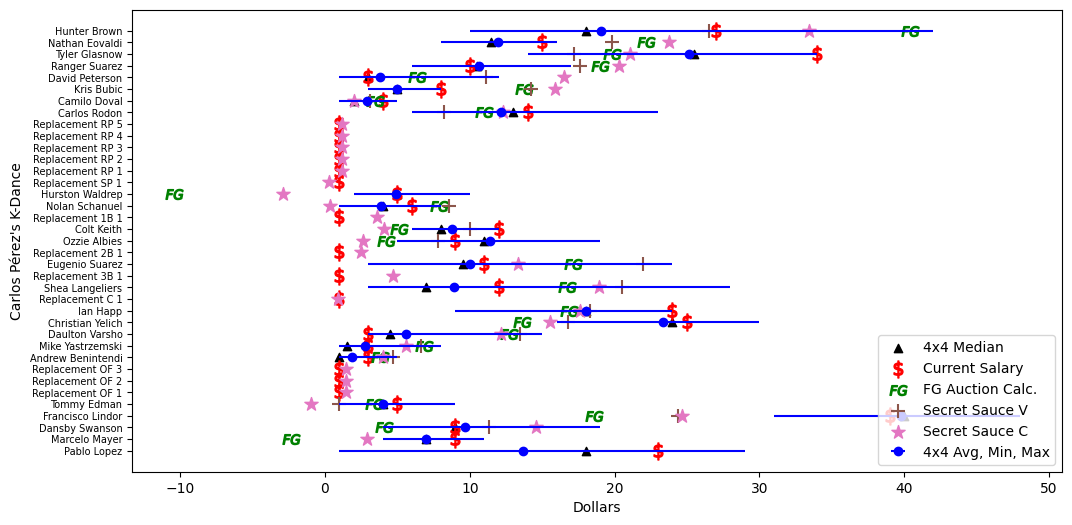

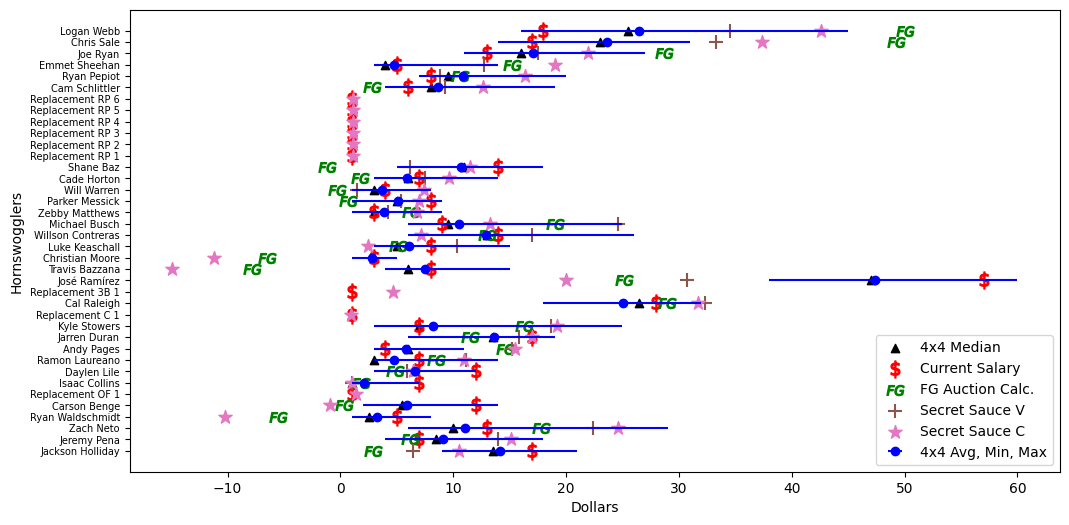

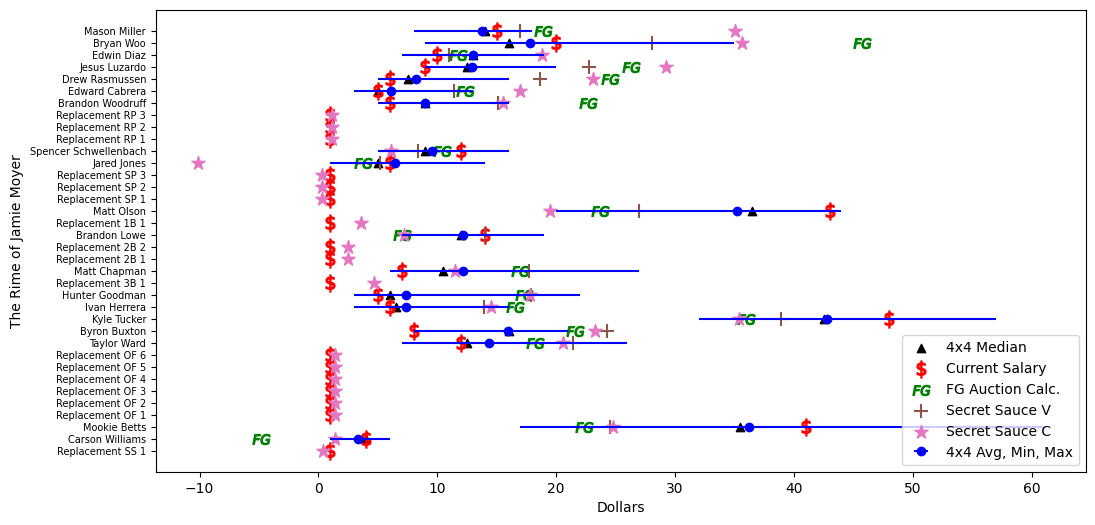

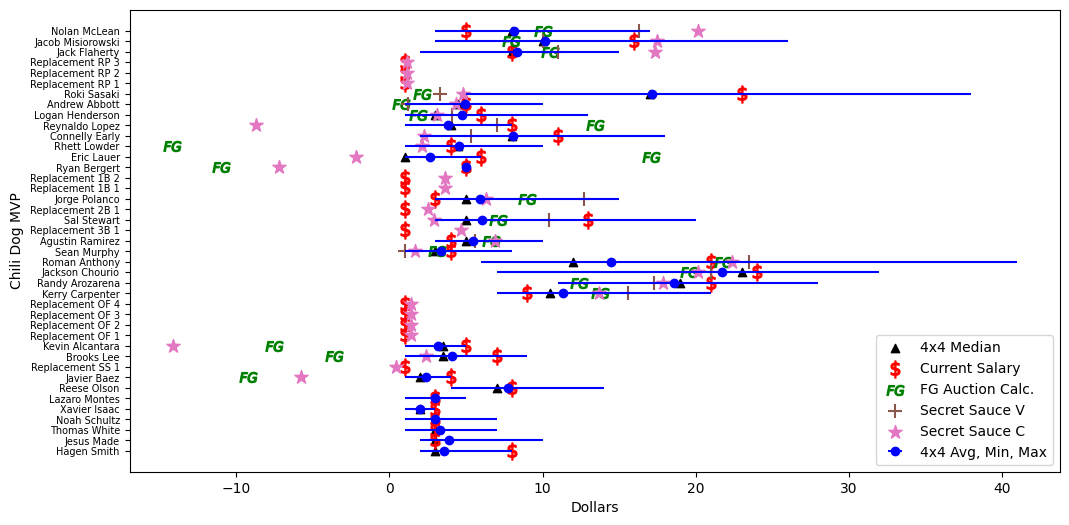

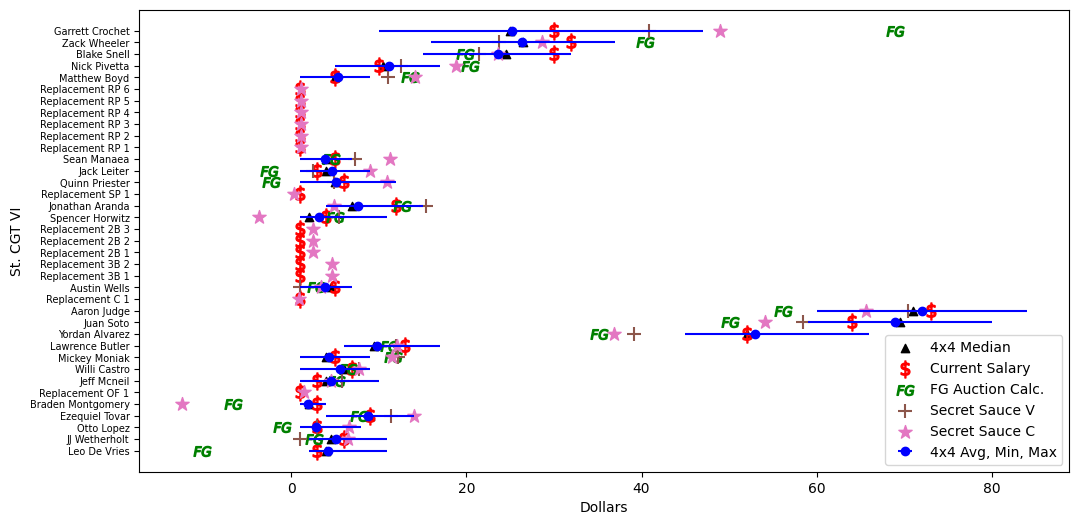

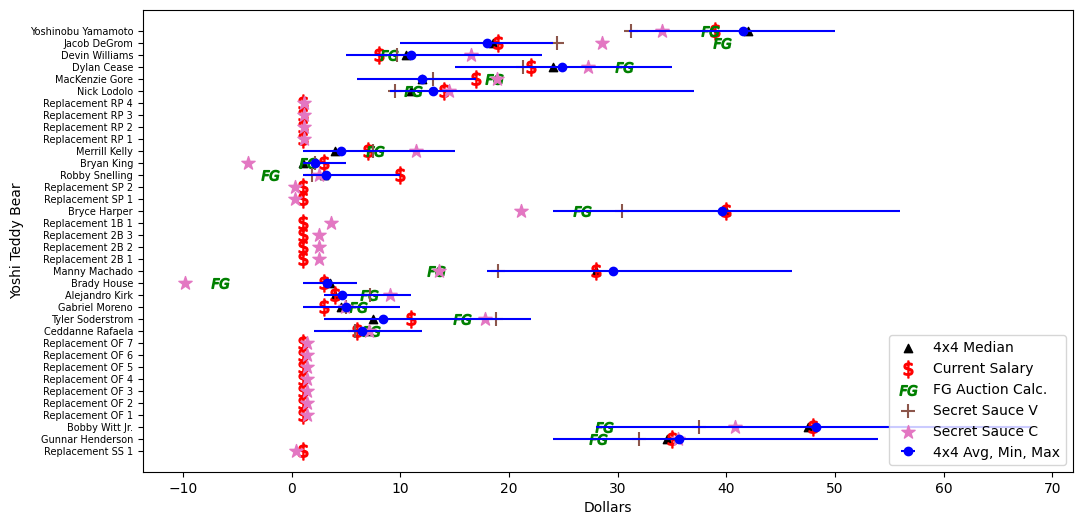

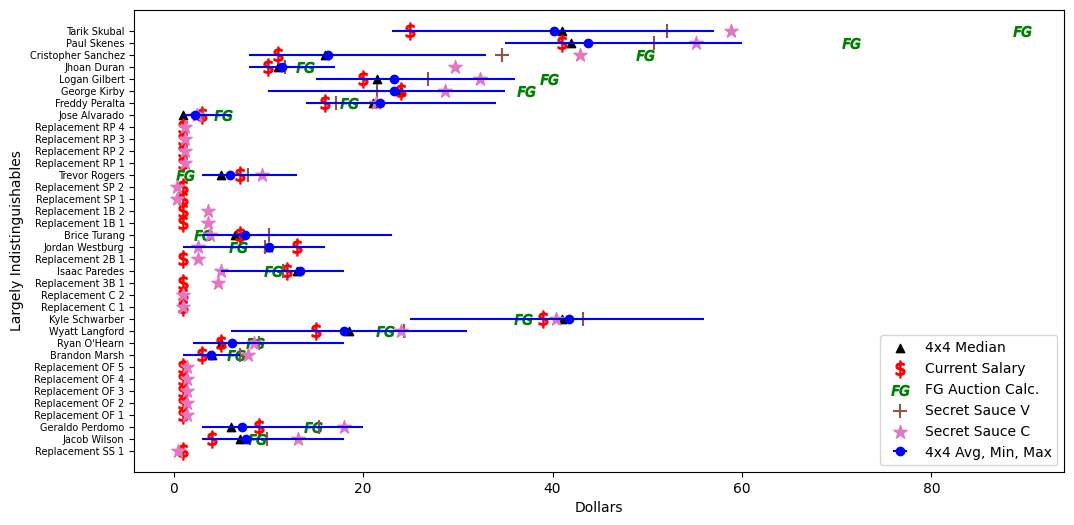

/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


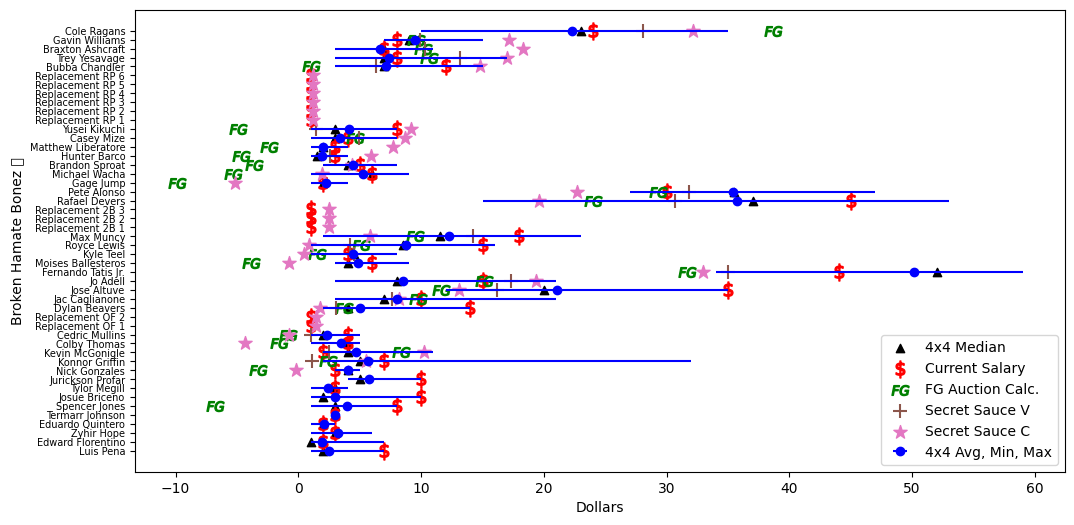

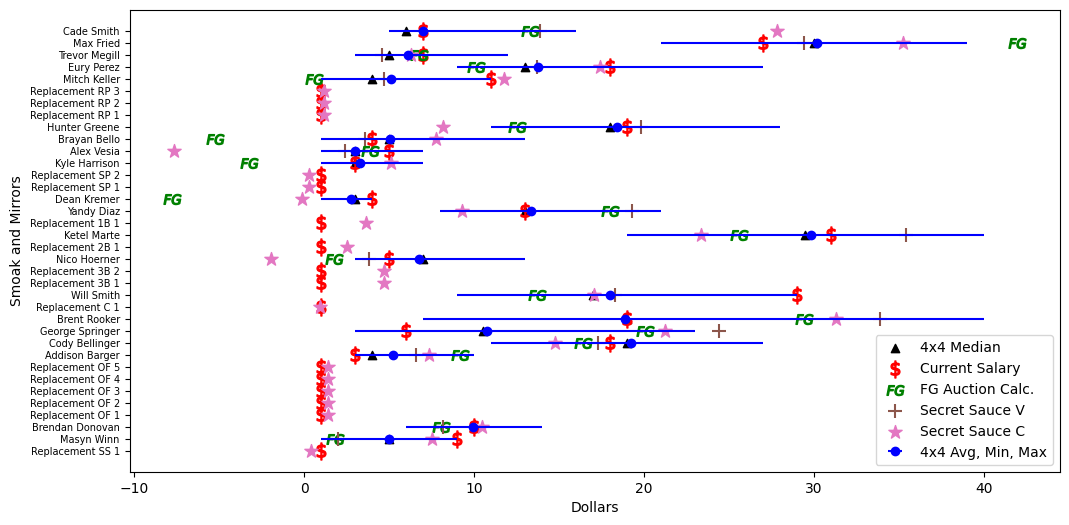

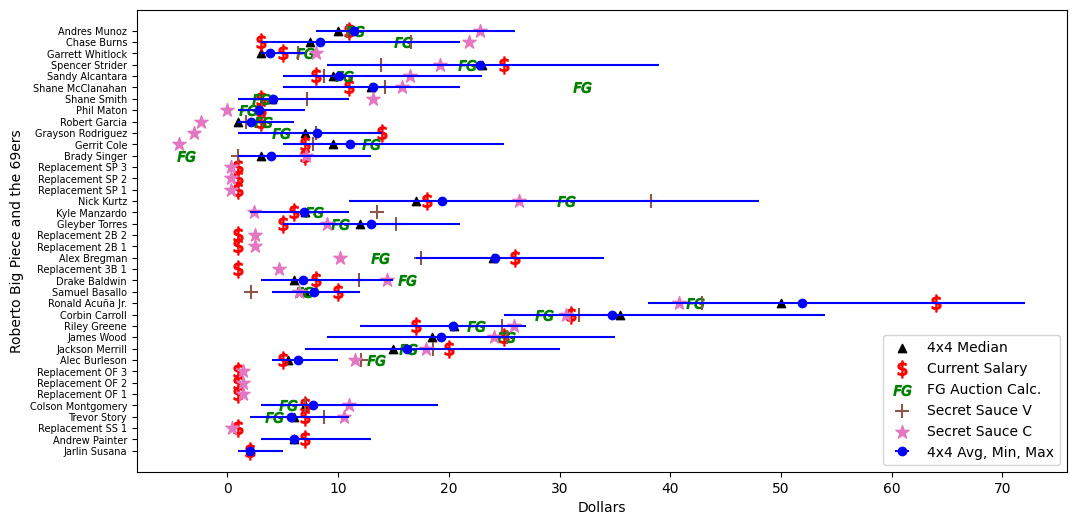

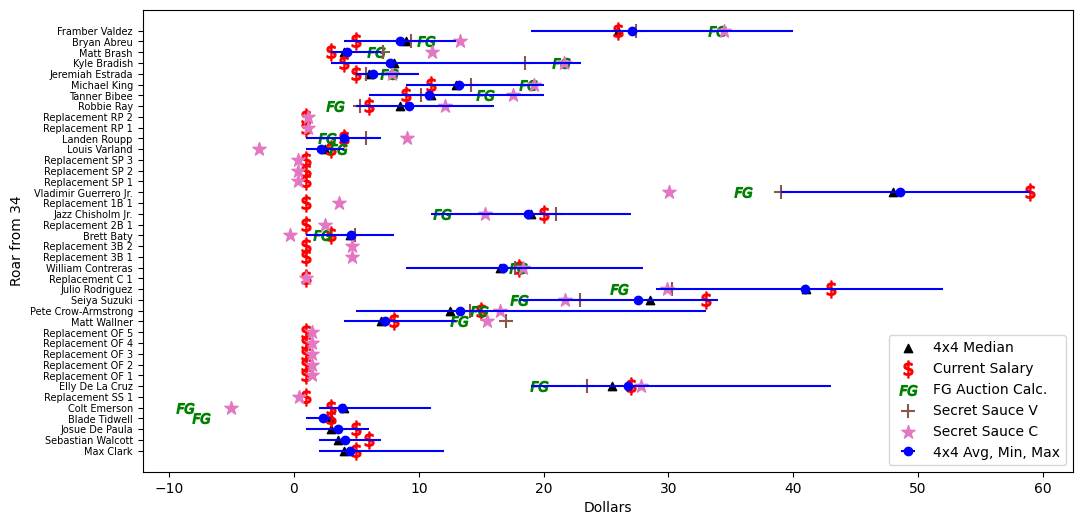

In [19]:
for team_id in All_Teams_df['TeamID'].unique():
    This_team_df = All_Teams_df[All_Teams_df['TeamID'] == team_id]
    team_name = All_Teams_df[All_Teams_df['TeamID'] == team_id]['Team Name'].unique()[0]
    quick_plotting_fn(This_team_df,team_name)

,Team Name,TOTAL_SGP_Val_mySGP
0,Chili Dog MVP,151.79
1,Jack Klugman's Second Best Lung,164.07
2,Smoak and Mirrors,280.28
3,Broken Hamate Bonez 🦴,283.77
4,Carlos Pérez's K-Dance,299.86
5,Yoshi Teddy Bear,316.51
6,Roar from 34,340.32
7,Hornswogglers,364.00
8,Roberto Big Piece and the 69ers,370.93
9,The Rime of Jamie Moyer,372.94


Target TOTAL_SGP_Val_mySGP: 500.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


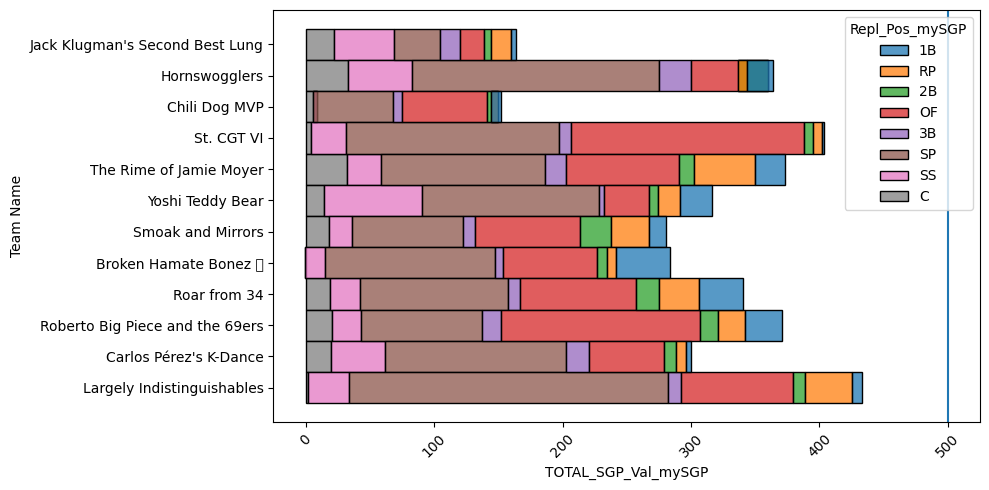

,Team Name,IP_mySGP_Team
0,Jack Klugman's Second Best Lung,1250.19
1,Chili Dog MVP,1412.11
2,Carlos Pérez's K-Dance,1500.00
3,Broken Hamate Bonez 🦴,1500.00
4,Hornswogglers,1500.00
5,Largely Indistinguishables,1500.00
6,Roberto Big Piece and the 69ers,1500.00
7,The Rime of Jamie Moyer,1500.00
8,Yoshi Teddy Bear,1500.00
9,Roar from 34,1500.00


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


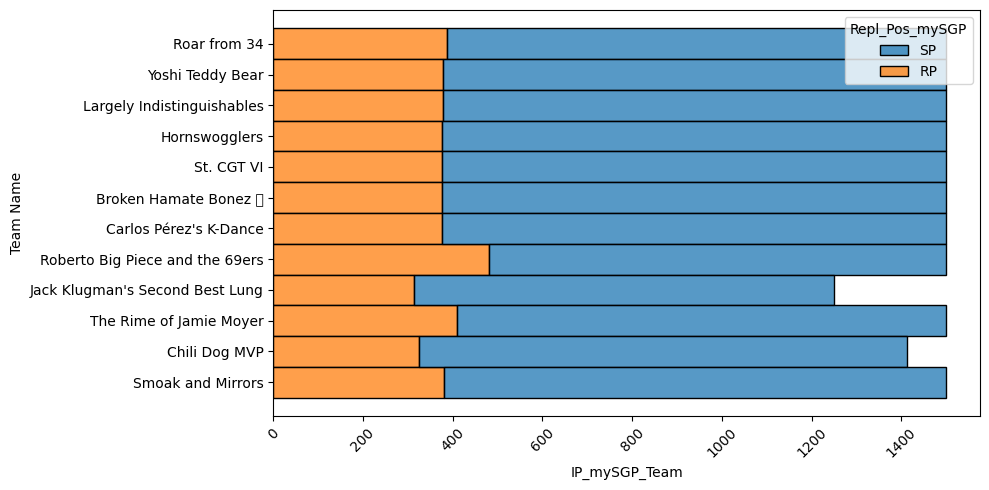

,Team Name,IP_FGAV_Team
0,Jack Klugman's Second Best Lung,1285.71
1,Chili Dog MVP,1389.34
2,Hornswogglers,1506.91
3,Smoak and Mirrors,1519.74
4,Largely Indistinguishables,1521.45
5,Yoshi Teddy Bear,1523.46
6,St. CGT VI,1524.32
7,Broken Hamate Bonez 🦴,1525.79
8,Roar from 34,1527.38
9,Carlos Pérez's K-Dance,1533.89


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


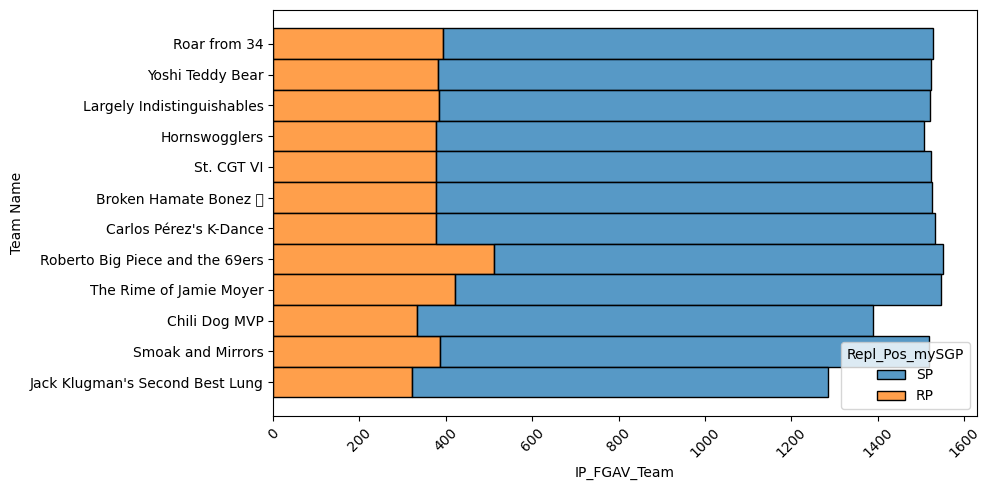

,Team Name,Salary
0,Jack Klugman's Second Best Lung,229.0
1,Chili Dog MVP,255.0
2,Smoak and Mirrors,264.0
3,Largely Indistinguishables,282.0
4,The Rime of Jamie Moyer,294.0
5,Carlos Pérez's K-Dance,326.0
6,Yoshi Teddy Bear,335.0
7,Roar from 34,340.0
8,Hornswogglers,347.0
9,Roberto Big Piece and the 69ers,368.0


Target Salary: 380.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


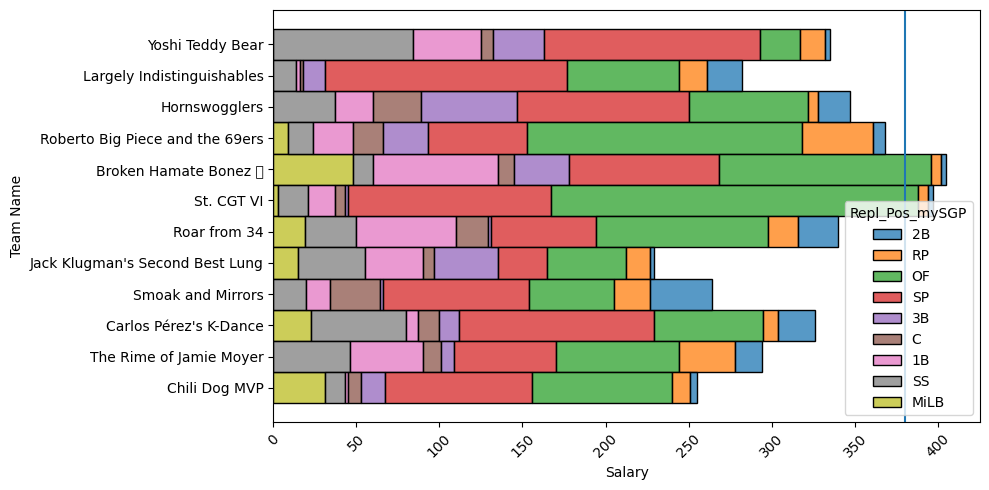

,Team Name,SO_mySGP_Team
0,Jack Klugman's Second Best Lung,1267.87
1,Chili Dog MVP,1422.27
2,Smoak and Mirrors,1522.31
3,Roberto Big Piece and the 69ers,1544.85
4,Carlos Pérez's K-Dance,1550.18
5,Roar from 34,1554.11
6,Broken Hamate Bonez 🦴,1564.84
7,The Rime of Jamie Moyer,1593.36
8,Yoshi Teddy Bear,1607.63
9,Hornswogglers,1630.57


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


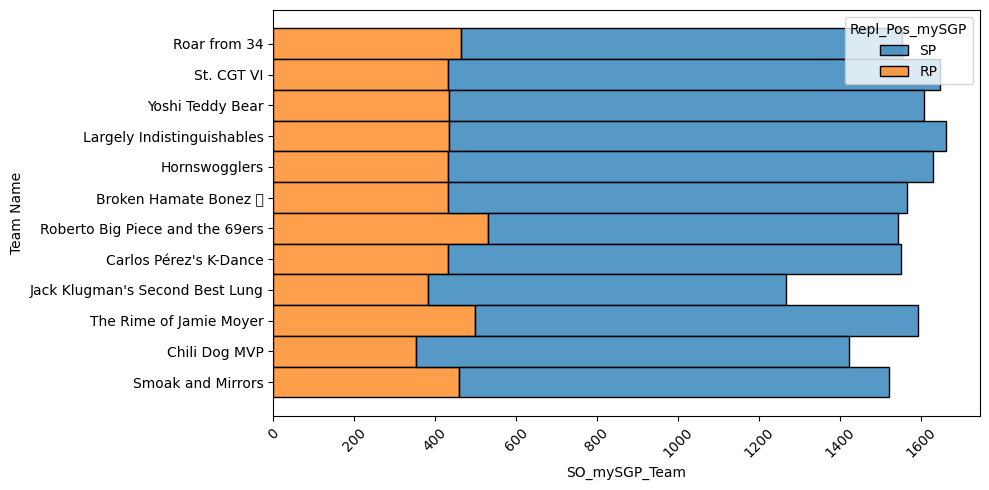

,Team Name,SO_SGP_Val_mySGP_Team
0,Jack Klugman's Second Best Lung,27.93
1,Chili Dog MVP,98.06
2,Smoak and Mirrors,110.27
3,The Rime of Jamie Moyer,139.57
4,Roar from 34,144.70
5,Carlos Pérez's K-Dance,149.24
6,Yoshi Teddy Bear,158.22
7,Roberto Big Piece and the 69ers,161.42
8,Broken Hamate Bonez 🦴,163.05
9,Hornswogglers,180.41


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


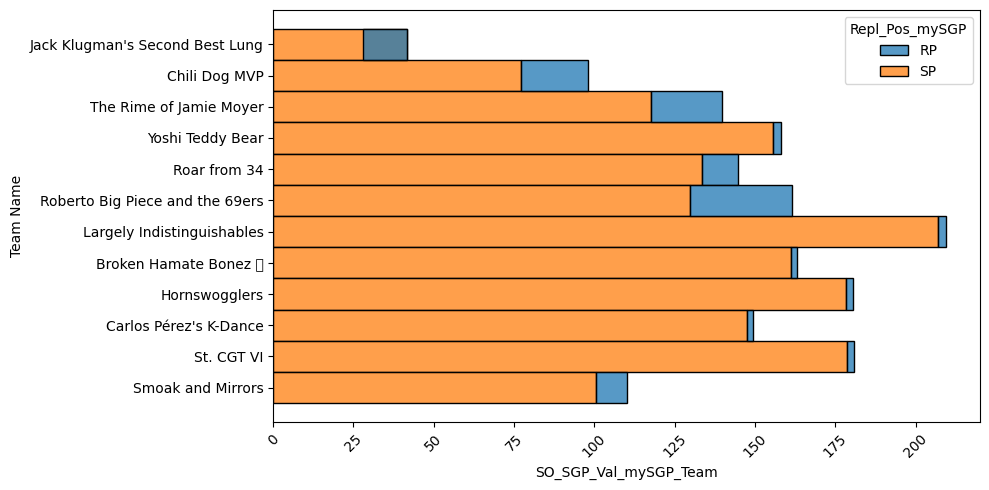

,Team Name,HR9_Team
0,Jack Klugman's Second Best Lung,0.64
1,Carlos Pérez's K-Dance,0.78
2,Largely Indistinguishables,0.79
3,The Rime of Jamie Moyer,0.79
4,Smoak and Mirrors,0.82
5,Broken Hamate Bonez 🦴,0.83
6,Hornswogglers,0.84
7,Roar from 34,0.85
8,St. CGT VI,0.87
9,Yoshi Teddy Bear,0.88


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


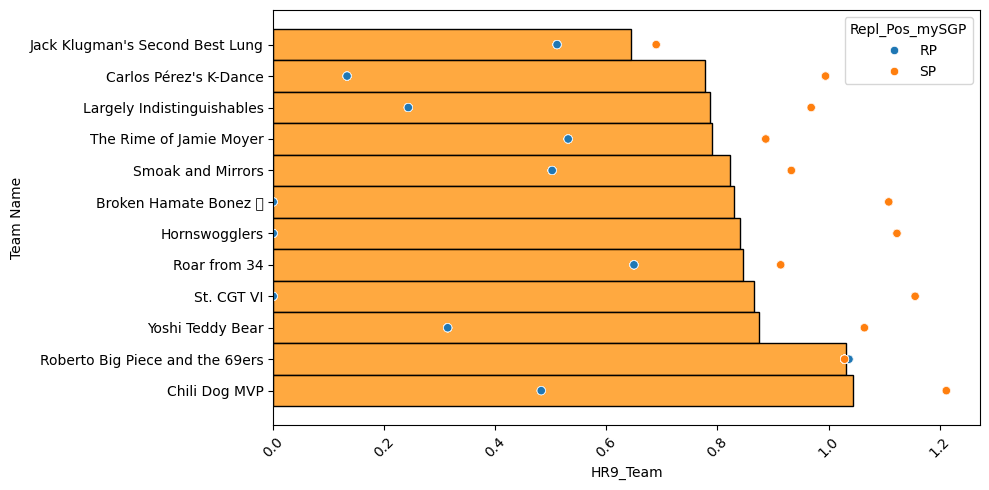

,Team Name,HR9_SGP_Val_mySGP_Team
0,Chili Dog MVP,-72.53
1,Roberto Big Piece and the 69ers,-55.38
2,Smoak and Mirrors,79.29
3,Jack Klugman's Second Best Lung,85.31
4,The Rime of Jamie Moyer,118.00
5,St. CGT VI,135.84
6,Yoshi Teddy Bear,161.26
7,Hornswogglers,184.39
8,Roar from 34,199.77
9,Broken Hamate Bonez 🦴,211.07


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


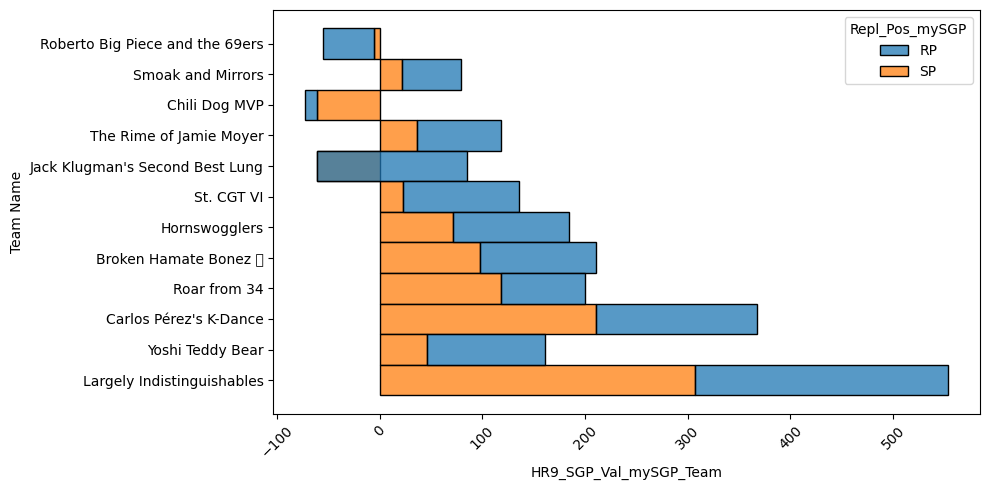

,Team Name,ERA_Team
0,Largely Indistinguishables,3.22
1,Hornswogglers,3.60
2,St. CGT VI,3.61
3,The Rime of Jamie Moyer,3.63
4,Yoshi Teddy Bear,3.69
5,Carlos Pérez's K-Dance,3.70
6,Roar from 34,3.75
7,Broken Hamate Bonez 🦴,3.81
8,Smoak and Mirrors,3.86
9,Roberto Big Piece and the 69ers,3.87


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


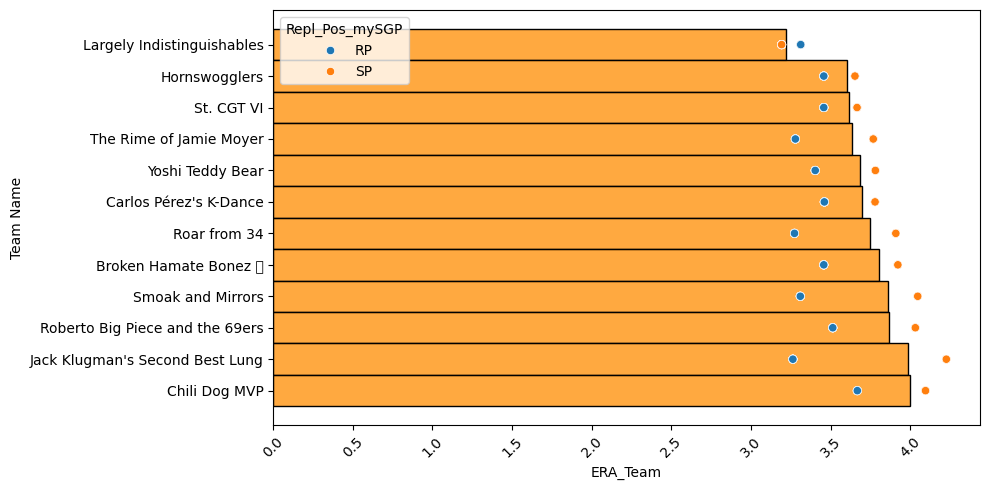

,Team Name,ERA_SGP_Val_mySGP_Team
0,Chili Dog MVP,53.07
1,Roberto Big Piece and the 69ers,73.58
2,Jack Klugman's Second Best Lung,86.11
3,Broken Hamate Bonez 🦴,112.94
4,Smoak and Mirrors,131.52
5,Carlos Pérez's K-Dance,140.58
6,Yoshi Teddy Bear,157.47
7,Roar from 34,161.98
8,St. CGT VI,171.00
9,Hornswogglers,171.43


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


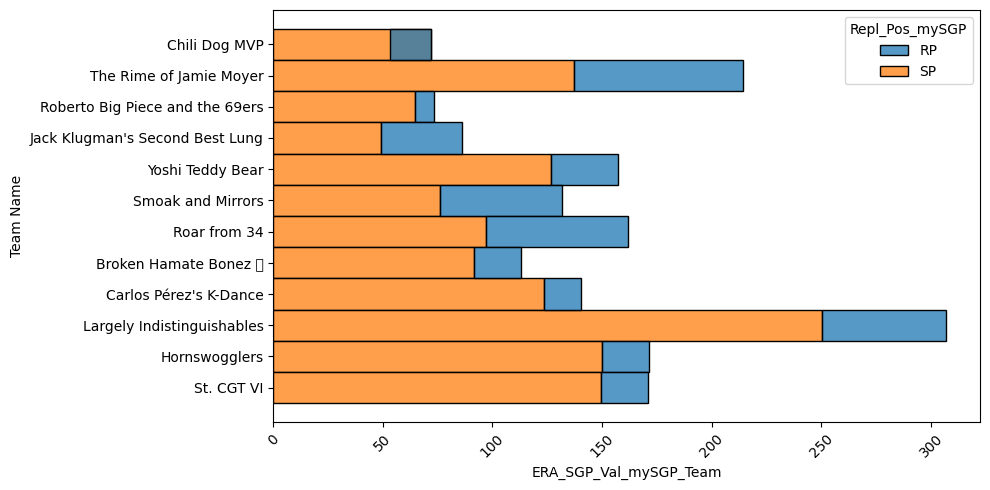

,Team Name,WHIP_Team
0,Largely Indistinguishables,1.12
1,The Rime of Jamie Moyer,1.18
2,St. CGT VI,1.18
3,Hornswogglers,1.18
4,Yoshi Teddy Bear,1.20
5,Carlos Pérez's K-Dance,1.23
6,Roberto Big Piece and the 69ers,1.23
7,Smoak and Mirrors,1.24
8,Roar from 34,1.24
9,Broken Hamate Bonez 🦴,1.25


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


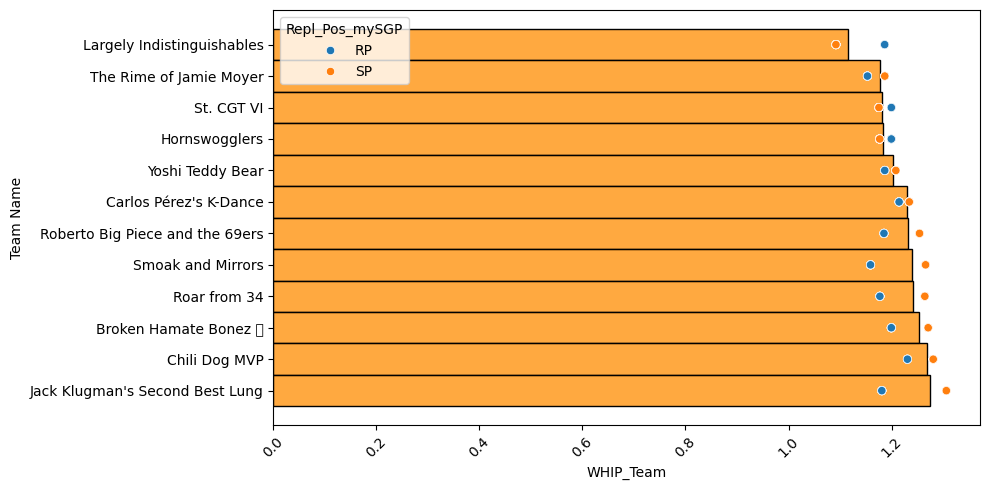

,Team Name,WHIP_SGP_Val_mySGP_Team
0,Chili Dog MVP,70.27
1,Jack Klugman's Second Best Lung,79.76
2,Broken Hamate Bonez 🦴,97.89
3,Carlos Pérez's K-Dance,112.00
4,Roar from 34,121.00
5,Roberto Big Piece and the 69ers,124.03
6,Smoak and Mirrors,165.40
7,Yoshi Teddy Bear,183.50
8,Hornswogglers,205.56
9,St. CGT VI,210.35


Index(['Target Pts', 'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary',
       'Hitter Pitcher', 'SO', 'HR9', 'ERA', 'WHIP', 'IP_mySGP', 'IP_FGAV'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


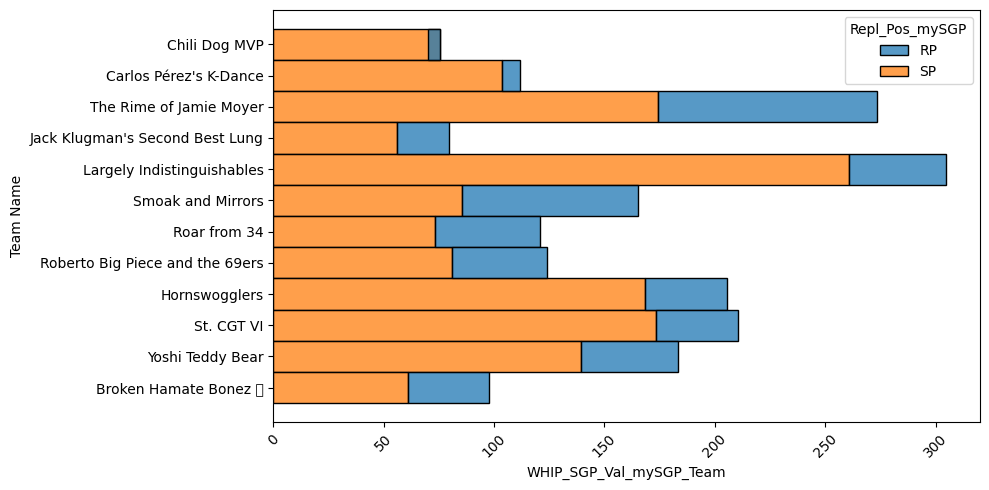

,Team Name,TOTAL_SGP_Val_mySGP
0,Chili Dog MVP,151.79
1,Jack Klugman's Second Best Lung,164.07
2,Smoak and Mirrors,280.28
3,Broken Hamate Bonez 🦴,283.77
4,Carlos Pérez's K-Dance,299.86
5,Yoshi Teddy Bear,316.51
6,Roar from 34,340.32
7,Hornswogglers,364.00
8,Roberto Big Piece and the 69ers,370.93
9,The Rime of Jamie Moyer,372.94


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Target TOTAL_SGP_Val_mySGP: 500.0


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


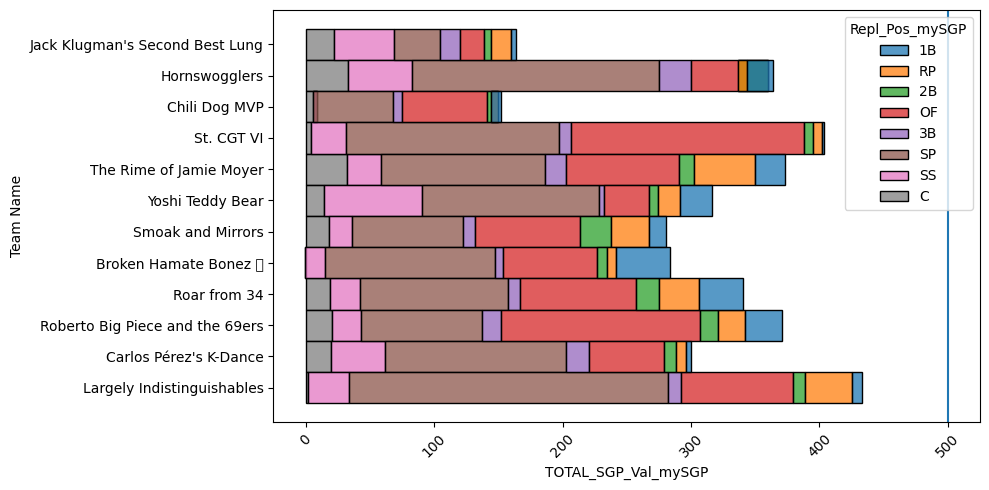

,Team Name,G_mySGP_Team
0,Broken Hamate Bonez 🦴,1944.0
1,Carlos Pérez's K-Dance,1944.0
2,Chili Dog MVP,1944.0
3,Hornswogglers,1944.0
4,Jack Klugman's Second Best Lung,1944.0
5,Largely Indistinguishables,1944.0
6,Roar from 34,1944.0
7,Roberto Big Piece and the 69ers,1944.0
8,Smoak and Mirrors,1944.0
9,St. CGT VI,1944.0


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


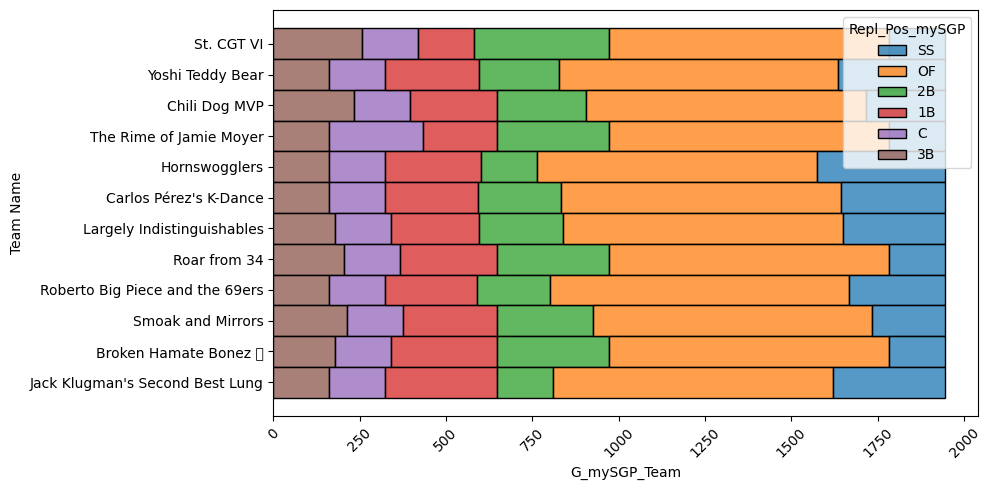

,Team Name,PA_mySGP_Team
0,Chili Dog MVP,8152.99
1,Yoshi Teddy Bear,8160.40
2,Largely Indistinguishables,8163.34
3,St. CGT VI,8176.30
4,Carlos Pérez's K-Dance,8183.30
5,Jack Klugman's Second Best Lung,8187.40
6,Broken Hamate Bonez 🦴,8195.62
7,Roar from 34,8200.26
8,Smoak and Mirrors,8203.92
9,Hornswogglers,8217.06


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


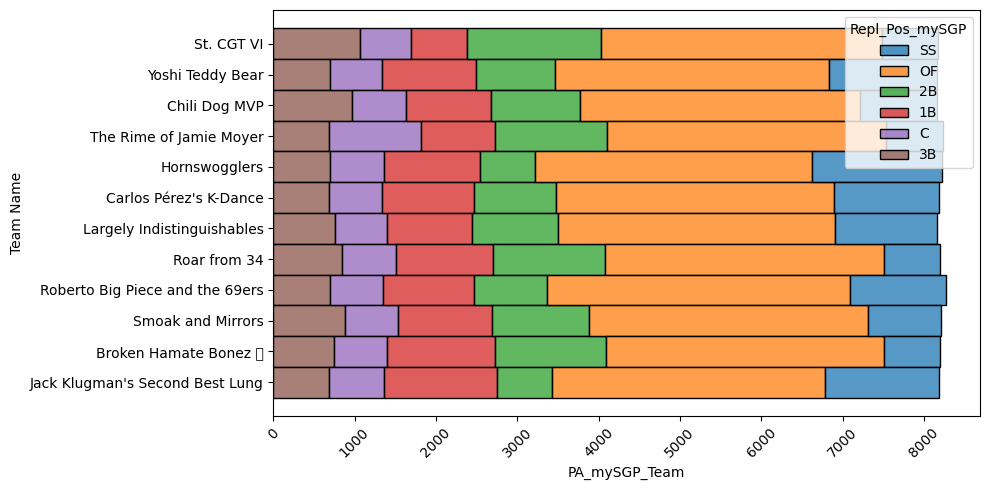

,Team Name,PA_FGAV_Team
0,Chili Dog MVP,8266.19
1,Yoshi Teddy Bear,8268.59
2,St. CGT VI,8275.90
3,Jack Klugman's Second Best Lung,8280.71
4,Roar from 34,8281.45
5,Largely Indistinguishables,8315.07
6,Smoak and Mirrors,8322.01
7,Broken Hamate Bonez 🦴,8346.35
8,Carlos Pérez's K-Dance,8384.61
9,Hornswogglers,8412.61


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


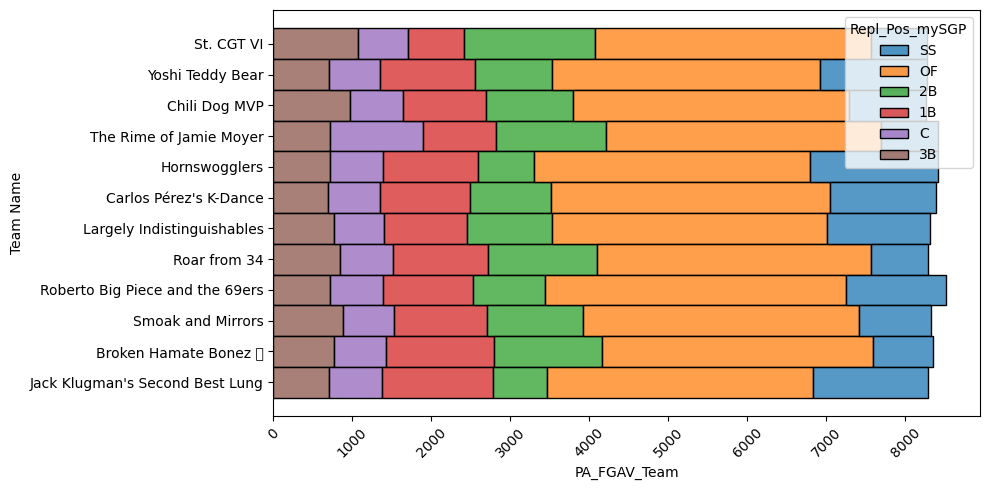

,Team Name,Salary
0,Jack Klugman's Second Best Lung,229.0
1,Chili Dog MVP,255.0
2,Smoak and Mirrors,264.0
3,Largely Indistinguishables,282.0
4,The Rime of Jamie Moyer,294.0
5,Carlos Pérez's K-Dance,326.0
6,Yoshi Teddy Bear,335.0
7,Roar from 34,340.0
8,Hornswogglers,347.0
9,Roberto Big Piece and the 69ers,368.0


Target Salary: 380.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


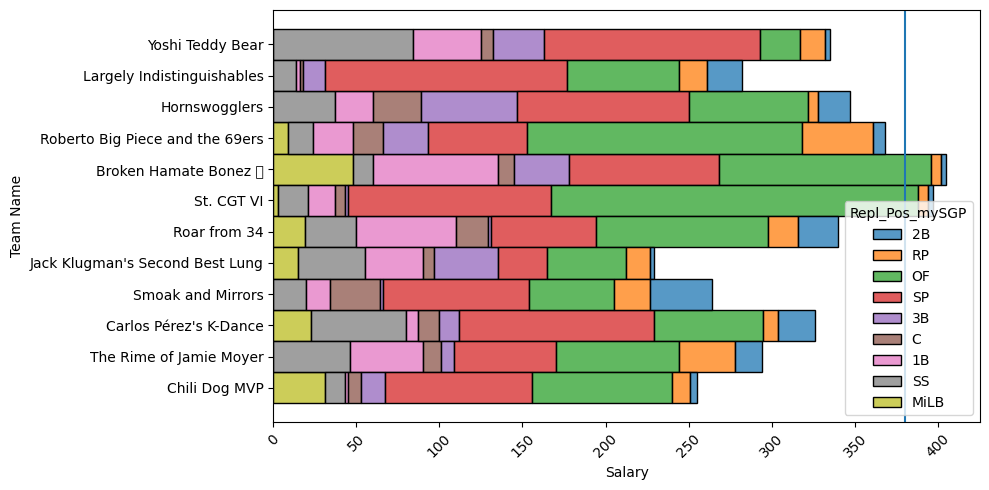

,Team Name,R_mySGP_Team
0,Chili Dog MVP,984.07
1,Jack Klugman's Second Best Lung,1000.73
2,Carlos Pérez's K-Dance,1006.62
3,Broken Hamate Bonez 🦴,1007.12
4,Smoak and Mirrors,1012.23
5,Yoshi Teddy Bear,1014.03
6,Largely Indistinguishables,1021.20
7,The Rime of Jamie Moyer,1039.46
8,St. CGT VI,1042.39
9,Roar from 34,1047.92


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


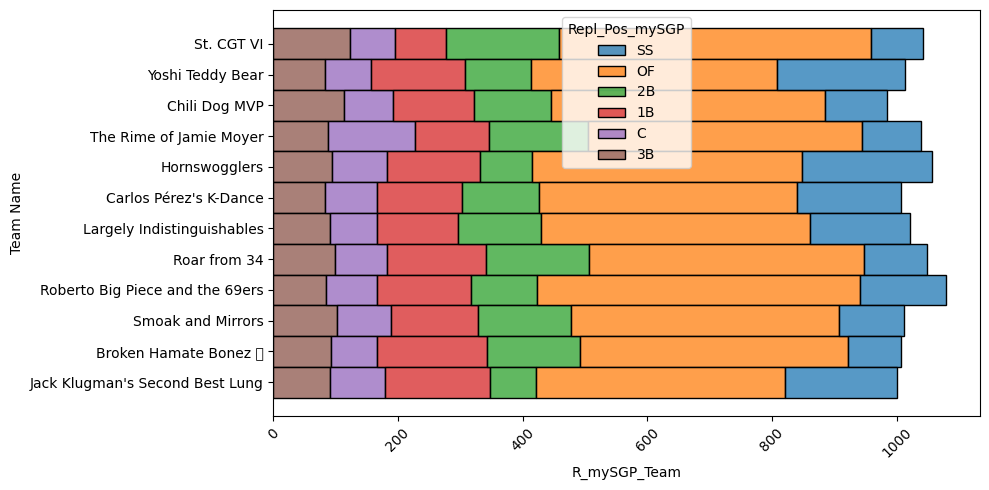

,Team Name,R_SGP_Val_mySGP_Team
0,Broken Hamate Bonez 🦴,111.52
1,Chili Dog MVP,113.86
2,Jack Klugman's Second Best Lung,135.36
3,Largely Indistinguishables,136.52
4,Smoak and Mirrors,152.96
5,Carlos Pérez's K-Dance,153.71
6,Yoshi Teddy Bear,158.95
7,The Rime of Jamie Moyer,186.77
8,St. CGT VI,192.27
9,Roar from 34,194.57


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


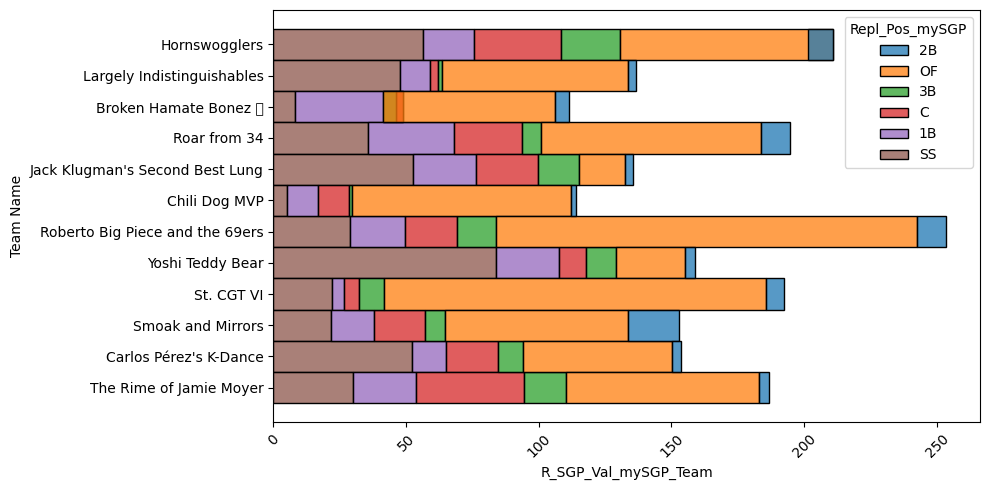

,Team Name,HR_mySGP_Team
0,Largely Indistinguishables,263.06
1,Chili Dog MVP,265.12
2,Yoshi Teddy Bear,269.94
3,Smoak and Mirrors,275.52
4,Jack Klugman's Second Best Lung,287.99
5,Carlos Pérez's K-Dance,289.31
6,Broken Hamate Bonez 🦴,293.46
7,Hornswogglers,294.89
8,Roar from 34,300.40
9,The Rime of Jamie Moyer,301.94


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


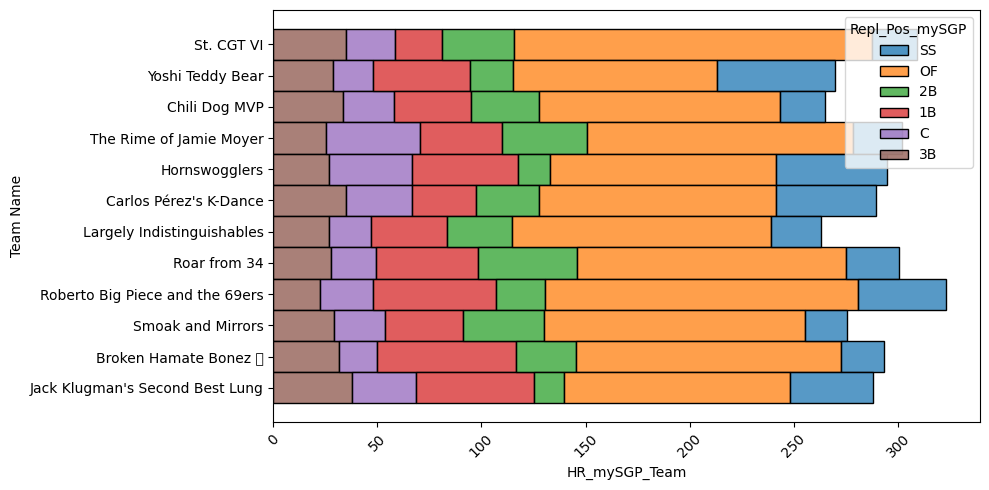

,Team Name,HR_SGP_Val_mySGP_Team
0,Largely Indistinguishables,107.05
1,Chili Dog MVP,114.33
2,Yoshi Teddy Bear,135.33
3,Smoak and Mirrors,140.50
4,Broken Hamate Bonez 🦴,152.48
5,Jack Klugman's Second Best Lung,155.45
6,Carlos Pérez's K-Dance,165.84
7,Hornswogglers,180.33
8,Roar from 34,188.79
9,The Rime of Jamie Moyer,193.66


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


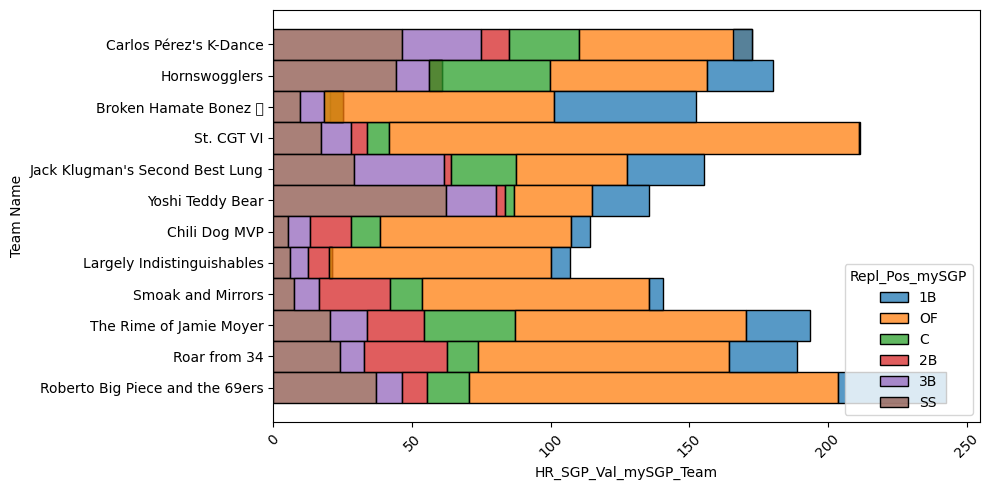

,Team Name,OBP_Team
0,Chili Dog MVP,0.32
1,Jack Klugman's Second Best Lung,0.32
2,Carlos Pérez's K-Dance,0.32
3,Yoshi Teddy Bear,0.33
4,Broken Hamate Bonez 🦴,0.33
5,The Rime of Jamie Moyer,0.33
6,Roar from 34,0.33
7,Hornswogglers,0.33
8,Smoak and Mirrors,0.33
9,Largely Indistinguishables,0.33


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


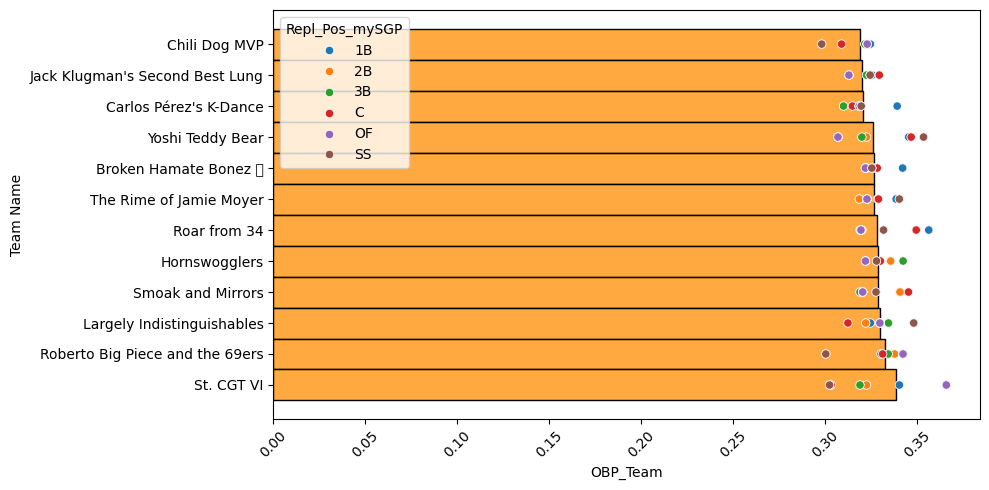

,Team Name,OBP_SGP_Val_mySGP_Team
0,Carlos Pérez's K-Dance,105.10
1,Jack Klugman's Second Best Lung,122.54
2,Chili Dog MVP,123.77
3,Hornswogglers,176.57
4,Broken Hamate Bonez 🦴,185.77
5,The Rime of Jamie Moyer,189.67
6,Roar from 34,209.07
7,Yoshi Teddy Bear,211.21
8,Roberto Big Piece and the 69ers,213.67
9,Smoak and Mirrors,221.33


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


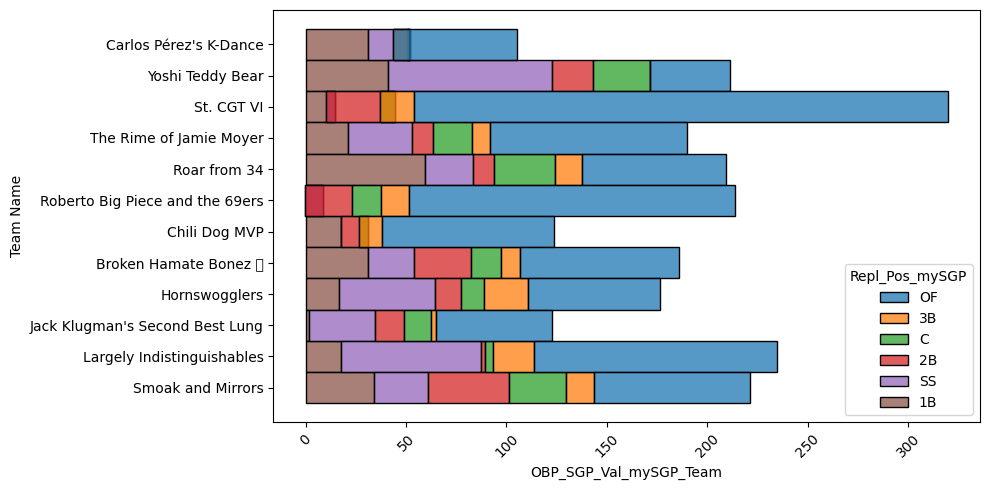

,Team Name,SLG_Team
0,Chili Dog MVP,0.41
1,Largely Indistinguishables,0.42
2,Carlos Pérez's K-Dance,0.42
3,Smoak and Mirrors,0.42
4,Jack Klugman's Second Best Lung,0.43
5,Broken Hamate Bonez 🦴,0.43
6,Yoshi Teddy Bear,0.43
7,The Rime of Jamie Moyer,0.43
8,Roar from 34,0.44
9,Hornswogglers,0.44


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


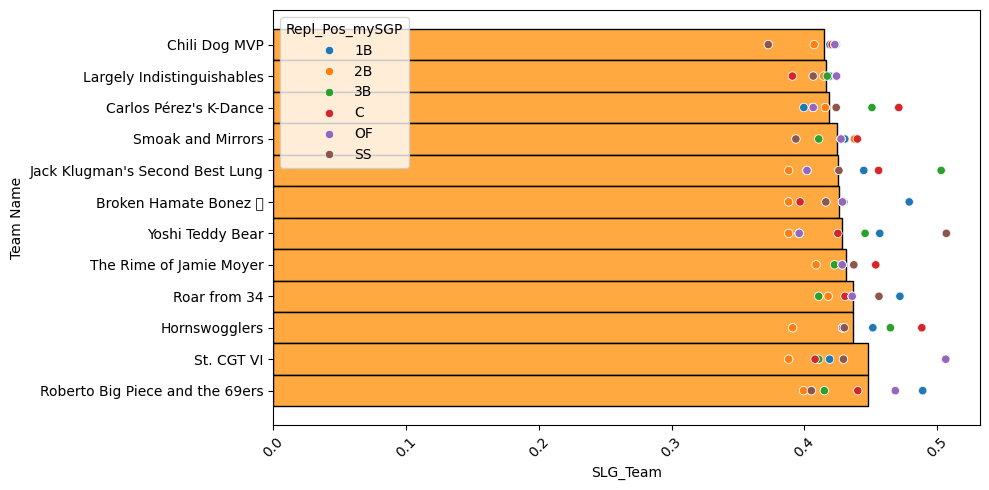

,Team Name,SLG_SGP_Val_mySGP_Team
0,Carlos Pérez's K-Dance,130.68
1,Chili Dog MVP,147.19
2,Largely Indistinguishables,149.06
3,Jack Klugman's Second Best Lung,179.30
4,Broken Hamate Bonez 🦴,180.72
5,Smoak and Mirrors,181.47
6,Hornswogglers,190.99
7,The Rime of Jamie Moyer,209.69
8,Yoshi Teddy Bear,214.81
9,Roar from 34,226.57


Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'G_mySGP', 'G_FGAV',
       'TOTAL_SGP_Val_mySGP', 'CAT_SGP_Val', 'Salary', 'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_43804/2144844903.py:37: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


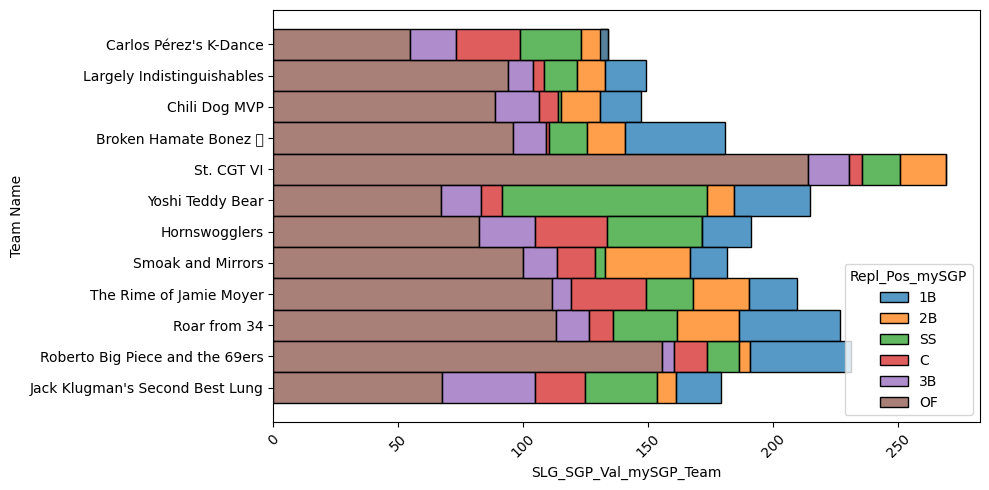

In [20]:
for pos in ['SP','Util']:
    This_Pos_Stat_Cats = Pitching_value_columns if pos in Pitching_Pos else Batting_value_columns
    for stat_cat, stat_cols in This_Pos_Stat_Cats.items():
        # if Stat in bugged_cols:
        #     continue
        # print(pos)
        # print(stat_cat)
        # print(All_teams_replacement_level[stat_cat])
        # fig1 = plt.figure(figsize=(10,5))
        # ax1 = fig1.add_subplot(111)
        # sns.histplot(All_teams_replacement_level,x='Team Name',weights=stat_cat,hue='Ottoneu Positions', multiple='stack',ax=ax1)
        # ax1.axhline(y=Target_Stats_df[stat_cat])
        # plt.tight_layout()
        # plt.show()
        
        

        for stat in stat_cols:
            # print(stat)
            fig2 = plt.figure(figsize=(10,5))
            ax2 = fig2.add_subplot(111)
            if stat in Team_Rate_Cols:
                sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index(),y='Team Name',weights=stat,color='darkorange',ax=ax2)
                sns.scatterplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat.replace('_','_pos_')),y='Team Name',x=stat.replace('_','_pos_'),hue='Repl_Pos_mySGP',ax=ax2)
                display(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index())
            else:
                sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).sort_values(stat),y='Team Name',weights=stat,hue='Repl_Pos_mySGP', multiple='stack',ax=ax2)
                display(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].sum().sort_values().reset_index())
            ax2.tick_params(axis='x', labelrotation=45)
            ax2.set_xlabel(stat)
            ax2.set_ylabel('Team Name')
            if (stat in Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns):
                ax2.axvline(x=Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0],label='Target')
                print(f'Target {stat}:', Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0])
            else:
                print(Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns)
            plt.tight_layout()
            plt.show()
            #sns.histplot(All_teams_replacement_level.dropna(subset=stat),y=stat,hue=)